<a href="https://colab.research.google.com/github/omaryasser1907/FOOD-1O1-classification/blob/main/FOOD_101.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CUSTOM DATASET



In [ ]:
import torch
from torch import nn
device="cuda" if torch.cuda.is_available () else "cpu"
device


'cuda'

In [ ]:
from pathlib import Path
import requests
import zipfile
data_path=Path("data/")
image_path=data_path/"pizza_steak_sushi"
if image_path.is_dir():
  print(f"{image_path} is here ,skip downloading " )
else:
  print(f"{image_path} is not here , so start downloading")
  image_path.mkdir(parents=True,exist_ok=True)

with open(data_path/"pizza_steak_sushi.zip","wb")as f:
  request=requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip")
  f.write(request.content)
with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip","r")as zip_ref:
  print(f"unzipping zip file ")
  zip_ref.extractall(image_path)

data/pizza_steak_sushi is not here , so start downloading
unzipping zip file 


In [ ]:
# walking through the data
import os
def walk_through_data (dir_path):
  for dirpath,dirnames,filenames in os.walk(dir_path):
    print(f"there are {len(dirnames)} :directories and {len(filenames)}: images in {dirpath} folder")

In [ ]:
walk_through_data(image_path)

there are 2 :directories and 0: images in data/pizza_steak_sushi folder
there are 3 :directories and 0: images in data/pizza_steak_sushi/test folder
there are 0 :directories and 19: images in data/pizza_steak_sushi/test/steak folder
there are 0 :directories and 25: images in data/pizza_steak_sushi/test/pizza folder
there are 0 :directories and 31: images in data/pizza_steak_sushi/test/sushi folder
there are 3 :directories and 0: images in data/pizza_steak_sushi/train folder
there are 0 :directories and 75: images in data/pizza_steak_sushi/train/steak folder
there are 0 :directories and 78: images in data/pizza_steak_sushi/train/pizza folder
there are 0 :directories and 72: images in data/pizza_steak_sushi/train/sushi folder


In [ ]:
# setting train & test directories
train_dir=image_path/"train"
test_dir=image_path/"test"
train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [ ]:
# visualizing images
import random
from PIL import Image
random.seed(42)
image_path_list=list(image_path.glob("*/*/*.jpg"))
random_image=random.choice(image_path_list)
image_class=random_image.parent.stem
img=Image.open(random_image)
# printing all metadata
print(f"random image choice : {random_image}")
print(f"random image class : {image_class}")
print(f"random image height : {img.height}")
print(f"random image width : {img.width}")
#img

random image choice : data/pizza_steak_sushi/test/sushi/1434806.jpg
random image class : sushi
random image height : 512
random image width : 512


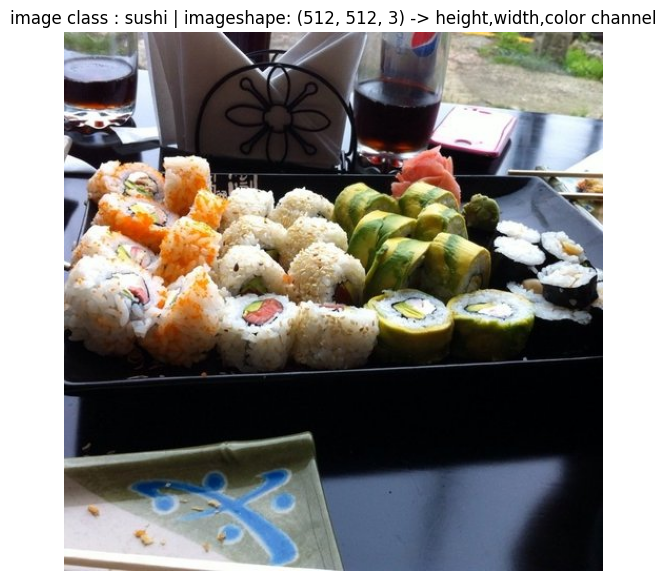

In [ ]:
# matplot visualizing
import numpy as np
import matplotlib.pyplot as plt
img_as_array=np.asarray(img)
# plotting
plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"image class : {image_class} | imageshape: {img_as_array.shape} -> height,width,color channel")
plt.axis(False) ;

In [ ]:
!pip install torchvision

In [ ]:
from torch.utils.data import DataLoader
from torchvision import transforms,datasets
data_transforms=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])


In [ ]:
data_transforms(img).shape

torch.Size([3, 64, 64])

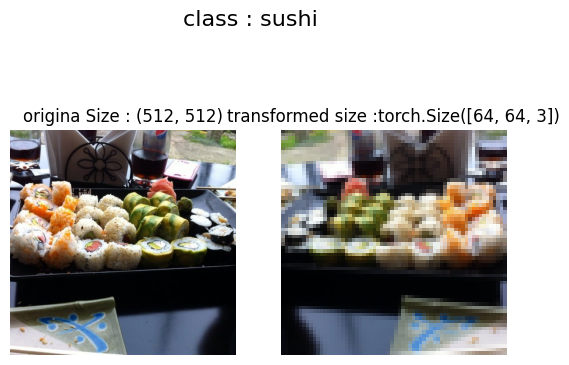

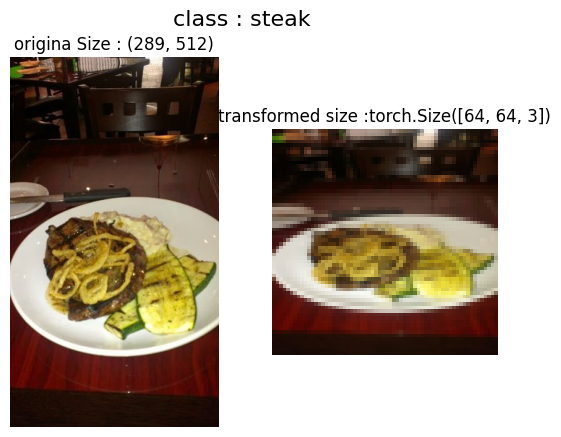

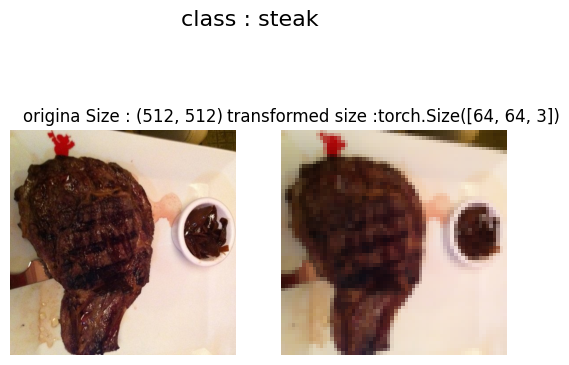

In [ ]:
# plotting original vs transformed images
def plot_transformed_image (image_paths:list,
                            transform,
                            n=3,
                            seed=None):
  if seed :
    random.seed(seed)
  random_image_paths=random.sample(image_path_list,k=n)
  for image_path in (random_image_paths):
    with Image.open(image_path)as f :
      fig,ax=plt.subplots(nrows=1,ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"origina Size : {f.size}")
      ax[0].axis(False)
      transformed_image=transform(f).permute(1,2,0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"transformed size :{transformed_image.shape}")
      ax[1].axis(False)
      fig.suptitle(f"class : {image_path.parent.stem}",fontsize=16 )
plot_transformed_image(image_paths=image_path_list,
                       transform=data_transforms,
                       n=3,
                       seed=42)



In [ ]:
## loading data using ImageFolder
from torchvision import datasets
train_data=datasets.ImageFolder(root=train_dir,
                                transform=data_transforms,
                                target_transform=None)
test_data=datasets.ImageFolder(root=test_dir,
                                transform=data_transforms,
                                target_transform=None)


In [ ]:
train_data,test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [ ]:
class_names=train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [ ]:
# creating classes dictionary
classes_dict=train_data.class_to_idx
classes_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [ ]:
len(train_data),len(test_data)

(225, 75)

In [ ]:
# indexing one image and label to work on
img,label=train_data[0][0],train_data[0][1]
print(f"image tensor :\n {img}")
print(f"image shape : {img.shape }")
print(f"image type : {img.dtype}")
print(f"image label : {label}")
print(f"label data type : {type(label)}")


image tensor :
 tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.

 original img shape : torch.Size([3, 64, 64])
 permuted img shape : torch.Size([64, 64, 3])


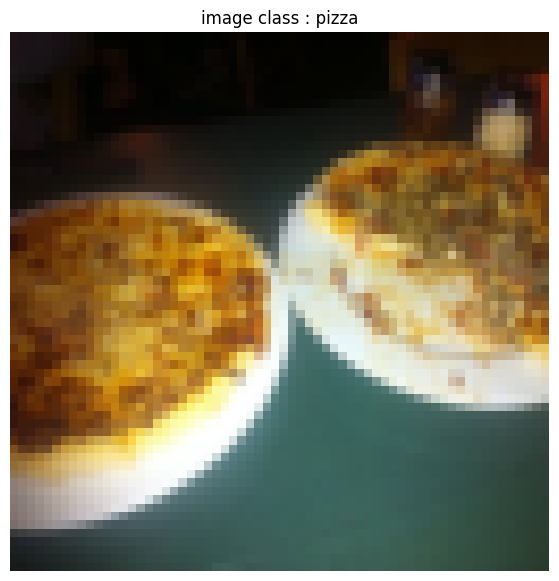

In [ ]:
# plotting the selected image
img_permute=img.permute(1,2,0)

plt.figure(figsize=(10,7))
plt.imshow(img_permute)
plt.axis(False)
plt.title(f"image class : {class_names[label]}")
# printing original shape vs permuted shape
print(f" original img shape : {img.shape}")
print(f" permuted img shape : {img_permute.shape}")

## let's create DATALOADER


In [ ]:
from torch.utils.data import DataLoader
BATCHSIZE=32
train_dataloader=DataLoader(dataset=train_data,
                            batch_size=BATCHSIZE,
                            num_workers=1,
                            shuffle=True)
test_dataloader=DataLoader(dataset=test_data ,
                           batch_size=BATCHSIZE,
                           num_workers=1,
                           shuffle=None)
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7c2008ea1010>,
 <torch.utils.data.dataloader.DataLoader at 0x7c1fe7715310>)

In [ ]:
len(train_dataloader),len(test_dataloader)

(8, 3)

In [ ]:
len(train_data),len(test_data)

(225, 75)

In [ ]:
## adding batch size dim on our img
img,label=next(iter(train_dataloader))
print(f"image shape : {img.shape} -> [batch_size,color_channel,height,width]")
print(f"label shape : {label.shape}")

image shape : torch.Size([32, 3, 64, 64]) -> [batch_size,color_channel,height,width]
label shape : torch.Size([32])


In [ ]:
# augentations using TrivialAugmenWide
from torchvision import transforms
train_transform=transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])
test_transform=transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.ToTensor()
])

In [ ]:
image_path

PosixPath('data/pizza_steak_sushi')

In [ ]:
image_path_list=list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/test/steak/502076.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/894825.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/100274.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1302563.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1627703.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/690177.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/2117351.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/673127.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/354513.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/27415.jpg')]

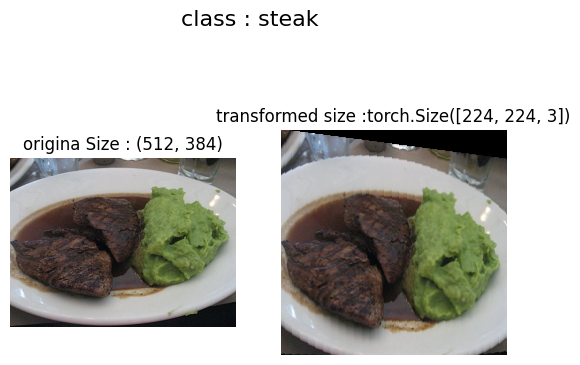

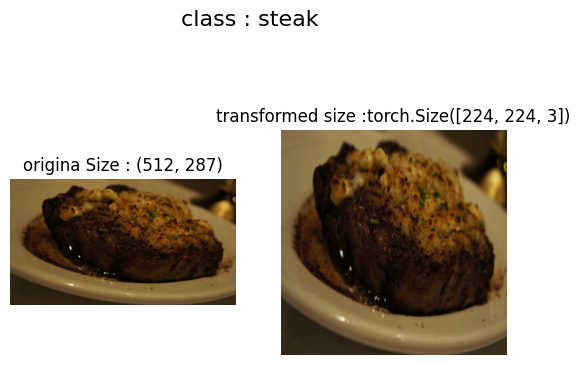

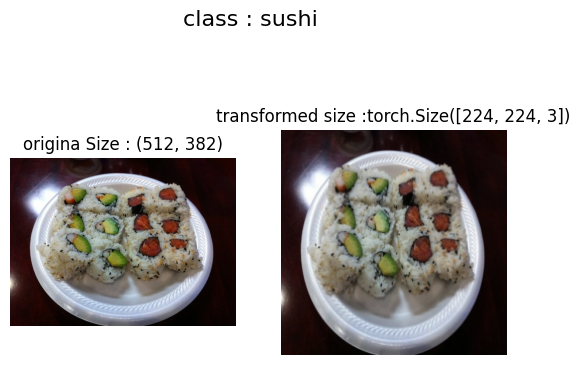

In [ ]:
# let's plot
plot_transformed_image(image_paths=image_path_list,
                       transform=train_transform,
                       n=3,
                       seed=None)

## model using TINY VGG

In [ ]:
## CREATING AND LOADING DATA FOR FIRST MODEL
from torchvision import transforms
simple_transform= transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()

])

In [ ]:
from torchvision import datasets
train_data_model0=datasets.ImageFolder(
    root=train_dir,
    transform=simple_transform,
    target_transform=None
)
test_data_model0= datasets.ImageFolder(
    root=test_dir,
    transform=simple_transform,
    target_transform=None
)



In [ ]:
# datsets to dataloader
from torch.utils.data import DataLoader
BATCH_SIZE=32
train_dataloader_model0=DataLoader(
    dataset=train_data_model0,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=os.cpu_count()
)
test_dataloader_model0=DataLoader(
    dataset=test_data_model0,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=os.cpu_count()
)


In [ ]:
len(train_dataloader_model0),len(test_dataloader_model0)

(8, 3)

In [ ]:
class TinyVGG (nn.Module):
  def __init__ (self,input_shape:int,
                    output_shape:int,
                    hidden_units:int) -> None:
    super().__init__()
    self.conv_block_1=nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  padding=0,
                  stride=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
        )
    self.conv_block_2=nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  padding=0,
                  stride=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
        )
    self.classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*13*13,
                  out_features=output_shape)
    )
  def forward (self,x) :
    x=self.conv_block_1(x)
    #print(x.shape)
    x=self.conv_block_2(x)
    #print(x.shape)
    x=self.classifier(x)
    #print(x.shape)
    return x



In [ ]:
# creating an instance
torch.manual_seed(42)
model_0=TinyVGG(input_shape=3, # num of color channels
                output_shape=len(class_names),
                hidden_units=10).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [ ]:
# passing a batch of the data to the model
image_batch,label_batch=next(iter(train_dataloader_model0))
image_batch.shape,label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [ ]:
model_0(image_batch.to(device))

tensor([[ 2.0795e-02, -1.9510e-03,  9.5212e-03],
        [ 1.8440e-02,  2.4669e-03,  6.6609e-03],
        [ 1.7695e-02,  1.0282e-03,  9.4975e-03],
        [ 2.4446e-02, -3.3489e-03,  9.5877e-03],
        [ 1.9939e-02,  6.9129e-04,  1.0778e-02],
        [ 2.1281e-02,  2.0434e-03,  5.0046e-03],
        [ 2.0996e-02,  1.6417e-04,  1.2481e-02],
        [ 2.1566e-02, -1.9607e-03,  9.7175e-03],
        [ 2.4500e-02, -4.7904e-03,  8.5394e-03],
        [ 2.0239e-02, -4.7980e-04,  1.0907e-02],
        [ 2.2219e-02, -4.1815e-04,  9.8173e-03],
        [ 2.2318e-02, -2.1642e-03,  9.4428e-03],
        [ 2.1851e-02, -3.7225e-03,  8.3784e-03],
        [ 2.2881e-02, -1.7559e-03,  1.0299e-02],
        [ 2.1635e-02, -4.3994e-03,  9.4990e-03],
        [ 2.2101e-02, -4.1469e-03,  9.3904e-03],
        [ 2.1226e-02, -4.4215e-03,  1.1476e-02],
        [ 2.1698e-02, -2.7458e-03,  8.4966e-03],
        [ 1.9974e-02, -3.2317e-07,  8.4496e-03],
        [ 1.8308e-02,  1.6378e-03,  8.5491e-03],
        [ 2.0768e-02

In [ ]:
# torchinfo to get model summary
! pip install torchinfo

In [ ]:
from torchinfo import summary
summary(model_0,[1,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

## train & test functions

In [ ]:
def train_step(model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               device=device):
  model.train()
  train_loss,train_acc=0,0
  for batch,(x,y) in enumerate (dataloader):
    x,y=x.to(device),y.to(device)
    y_pred=model(x)
    #train_loss+=loss_fn(y_pred,y)
    loss=loss_fn(y_pred,y)
    train_loss+=loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    y_pred_class=torch.argmax(torch.softmax(y_pred,dim=1),dim=1)
    train_acc+=(y_pred_class==y).sum().item()/len(y_pred)
  # average per batch
  train_loss/=len(dataloader)
  train_acc/=len(dataloader)
  return train_loss,train_acc


In [ ]:
def test_step (model:torch.nn.Module,
               dataloader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               device=device):
  model.eval()
  with torch.inference_mode():
    test_loss,test_acc=0,0
    for batch,(x,y) in enumerate(dataloader):
      x,y=x.to(device),y.to(device)
      test_pred=model(x)
      test_loss+=loss_fn(test_pred,y)
      test_pred_label=torch.argmax(torch.softmax(test_pred,dim=1),dim=1)
      test_acc+=(test_pred_label==y).sum().item()/len(test_pred_label)
    test_loss/=len(dataloader)
    test_acc/=len(dataloader)
  return test_loss,test_acc


In [ ]:
def train (model:torch.nn.Module ,
           optimizer,
           train_dataloader,
           test_dataloader,
           loss_fn:torch.nn.Module=nn.CrossEntropyLoss(),
           epochs=5,
           device=device):
  results={ "train_loss" :[],
            "train_acc" :[],
            "test_loss" :[],
            "test_acc" :[]}
  from tqdm.auto import tqdm
  for epoch in tqdm(range(epochs)):
    train_loss,train_acc=train_step(model=model,
                                    dataloader=train_dataloader,
                                    optimizer=optimizer,
                                    loss_fn=loss_fn,
                                    device=device
                                    )
    test_loss,test_acc=test_step(model=model,
                                 dataloader=test_dataloader,
                                 optimizer=optimizer,
                                 loss_fn=loss_fn,
                                 device=device)
    # printing what's happening
    print(f"epoch : {epoch} | train_loss: {train_loss:.4f}| train_acc: {train_acc:.4f} % | test_loss:{test_loss:.4f} | test_acc: {test_acc :.4f}%")
    results["test_acc"].append(test_acc)
    results["test_loss"].append(test_loss)
    results["train_acc"].append(train_acc)
    results["train_loss"].append(train_loss)
  return results


# training and evaluating MODEL_0

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

EPOCHS_NUM=5
# creating an instance
from timeit import default_timer as timer
start_time=timer()
model_0=TinyVGG(input_shape=3,
                hidden_units=10, # also len(class_names)
                output_shape=len(train_data.classes)).to(device)

loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=model_0.parameters(),
                           lr=0.001)
model_0_results=train(model=model_0,
                      train_dataloader=train_dataloader_model0,
                      test_dataloader=test_dataloader_model0,
                      optimizer=optimizer,
                      loss_fn=loss_fn,
                      epochs=EPOCHS_NUM,
                      device=device)
end_time=timer()
total_time=end_time-start_time
print(f"total training time : {total_time:.3f} seconds")



  0%|          | 0/5 [00:00<?, ?it/s]

epoch : 0 | train_loss: 1.1063| train_acc: 0.3047 % | test_loss:1.0983 | test_acc: 0.3011%
epoch : 1 | train_loss: 1.0998| train_acc: 0.3281 % | test_loss:1.0697 | test_acc: 0.5417%
epoch : 2 | train_loss: 1.0869| train_acc: 0.4883 % | test_loss:1.0809 | test_acc: 0.4924%
epoch : 3 | train_loss: 1.0846| train_acc: 0.3984 % | test_loss:1.0606 | test_acc: 0.5729%
epoch : 4 | train_loss: 1.0662| train_acc: 0.4219 % | test_loss:1.0657 | test_acc: 0.5644%
total training time : 10.805 seconds


In [ ]:
model_0_results

{'train_loss': [tensor(1.1063, device='cuda:0', grad_fn=<DivBackward0>),
  tensor(1.0998, device='cuda:0', grad_fn=<DivBackward0>),
  tensor(1.0869, device='cuda:0', grad_fn=<DivBackward0>),
  tensor(1.0846, device='cuda:0', grad_fn=<DivBackward0>),
  tensor(1.0662, device='cuda:0', grad_fn=<DivBackward0>)],
 'train_acc': [0.3046875, 0.328125, 0.48828125, 0.3984375, 0.421875],
 'test_loss': [tensor(1.0983, device='cuda:0'),
  tensor(1.0697, device='cuda:0'),
  tensor(1.0809, device='cuda:0'),
  tensor(1.0606, device='cuda:0'),
  tensor(1.0657, device='cuda:0')],
 'test_acc': [0.30113636363636365,
  0.5416666666666666,
  0.49242424242424243,
  0.5729166666666666,
  0.5643939393939394]}

In [ ]:
def plot_loss_curves(results:dict[str,list[float]]):
  #train and test loss
  loss=[l.item()for l in results["train_loss"]]
  test_loss=[l.item()for l in results["test_loss"]]
  # train and test acc
  accuracy=results["train_acc"]
  test_accuracy=results["test_acc"]

  epochs=range(len(results["train_loss"]))

  plt.figure(figsize=(15,7))
  #loss
  plt.subplot(1,2,1)
  plt.plot(epochs,loss,label="train_loss")
  plt.plot(epochs,test_loss,label="test_loss")
  plt.xlabel("epochs")
  plt.title("loss curve")
  plt.legend()
  # acc
  plt.subplot(1,2,2)
  plt.plot(epochs,accuracy,label="train_acc")
  plt.plot(epochs,test_accuracy,label="test_acc")
  plt.xlabel("epochs")
  plt.title("accuracy curve")
  plt.legend()

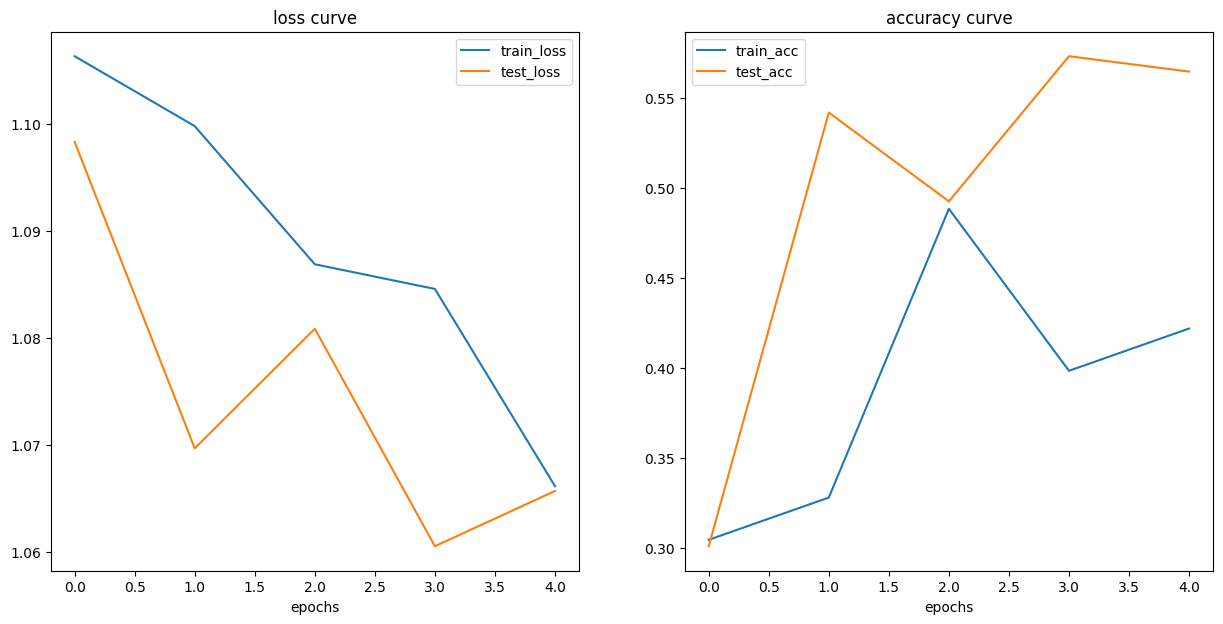

In [ ]:
plot_loss_curves(model_0_results)

let's enhance our model's results
using augmented data


In [ ]:
#creating traing and testing transform
from torchvision import transforms
train_transform_trivial= transforms.Compose([
          transforms.Resize(size=(64,64)),
          transforms.TrivialAugmentWide(num_magnitude_bins=31),
          transforms.ToTensor()
])
test_transform_simple=transforms.Compose([
          transforms.Resize(size=(64,64)),
          transforms.ToTensor()
])



In [ ]:
from torchvision import datasets
train_data_augmented=datasets.ImageFolder(root=train_dir,
                                          transform=train_transform_trivial)
test_data_simple=datasets.ImageFolder(root=test_dir,
                                      transform=test_transform_simple)


In [ ]:
from torch.utils.data import DataLoader
import os
num_workers=os.cpu_count()
BATCH_SIZE=32
train_dataloader_augmented=DataLoader(dataset=train_data_augmented,
                                      shuffle=True,
                                      num_workers=num_workers,
                                      batch_size=BATCH_SIZE)
test_dataloader_simple=DataLoader(dataset=test_data_simple,
                                  batch_size=BATCH_SIZE,
                                  num_workers=num_workers,
                                  shuffle=False  )

## constructing and training model_1

In [ ]:
torch.manual_seed(42)
model_1=TinyVGG(input_shape=3,
                hidden_units=10,
                output_shape=len(train_data_augmented.classes)).to(device)
model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs=5


# lets set the LOSS AND OPTIMIZER
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=model_1.parameters(),

                           lr=0.001)
start_time=timer()
model_1_results=train(model=model_1,
                      train_dataloader=train_dataloader_augmented,
                      test_dataloader=test_dataloader_simple,
                      loss_fn=loss_fn,
                      optimizer=optimizer,
                      device=device,
                      epochs=epochs
                      )
end_time=timer()
total_time=end_time-start_time
print(f"total time is : {total_time}")

  0%|          | 0/5 [00:00<?, ?it/s]

epoch : 0 | train_loss: 1.1049| train_acc: 0.2500 % | test_loss:1.1019 | test_acc: 0.2604%
epoch : 1 | train_loss: 1.0807| train_acc: 0.4258 % | test_loss:1.1260 | test_acc: 0.2604%
epoch : 2 | train_loss: 1.0713| train_acc: 0.4258 % | test_loss:1.1593 | test_acc: 0.2604%
epoch : 3 | train_loss: 1.1260| train_acc: 0.3047 % | test_loss:1.1583 | test_acc: 0.2604%
epoch : 4 | train_loss: 1.0854| train_acc: 0.4219 % | test_loss:1.1548 | test_acc: 0.3125%
total time is : 9.836656263999998


In [ ]:
model_1_results

{'train_loss': [tensor(1.1049, device='cuda:0', grad_fn=<DivBackward0>),
  tensor(1.0807, device='cuda:0', grad_fn=<DivBackward0>),
  tensor(1.0713, device='cuda:0', grad_fn=<DivBackward0>),
  tensor(1.1260, device='cuda:0', grad_fn=<DivBackward0>),
  tensor(1.0854, device='cuda:0', grad_fn=<DivBackward0>)],
 'train_acc': [0.25, 0.42578125, 0.42578125, 0.3046875, 0.421875],
 'test_loss': [tensor(1.1019, device='cuda:0'),
  tensor(1.1260, device='cuda:0'),
  tensor(1.1593, device='cuda:0'),
  tensor(1.1583, device='cuda:0'),
  tensor(1.1548, device='cuda:0')],
 'test_acc': [0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.3125]}

## PLOTTING

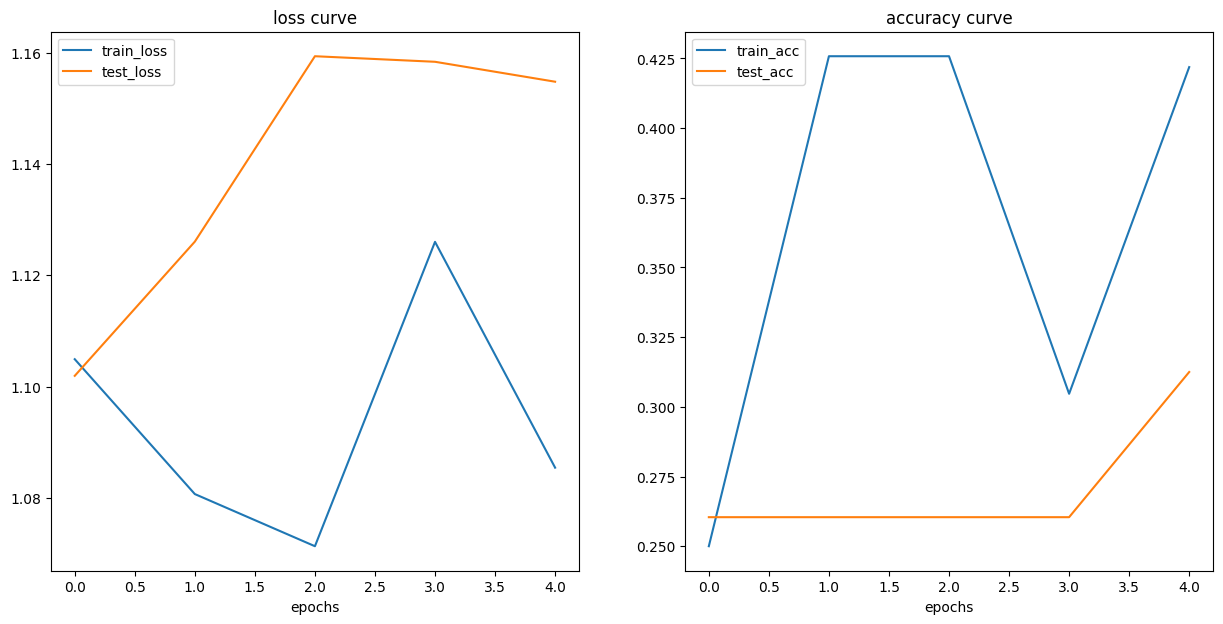

In [ ]:
plot_loss_curves(model_1_results)

## comparing all models results

In [ ]:
import pandas as pd
# dictionary comprehension and list comprehension
model_0_results_fixed={k:[ x.item() if torch.is_tensor(x) else x
                          for x in v ]
                       for k,v in model_0_results.items()}
model_1_results_fixed={ k:[x.item()if torch.is_tensor(x) else x
                           for x in v ]
                        for k,v in model_1_results.items()}
model_0_pd=pd.DataFrame(model_0_results_fixed)
model_1_pd=pd.DataFrame(model_1_results_fixed)
model_0_pd


,train_loss,train_acc,test_loss,test_acc
0,1.106320,0.304688,1.098320,0.301136
1,1.099793,0.328125,1.069701,0.541667
2,1.086891,0.488281,1.080868,0.492424
3,1.084586,0.398438,1.060559,0.572917
4,1.066168,0.421875,1.065719,0.564394


In [ ]:
model_1_pd

,train_loss,train_acc,test_loss,test_acc
0,1.104914,0.250000,1.101926,0.260417
1,1.080689,0.425781,1.126030,0.260417
2,1.071320,0.425781,1.159335,0.260417
3,1.125994,0.304688,1.158335,0.260417
4,1.085431,0.421875,1.154756,0.312500


In [ ]:
len(model_0_pd)

5

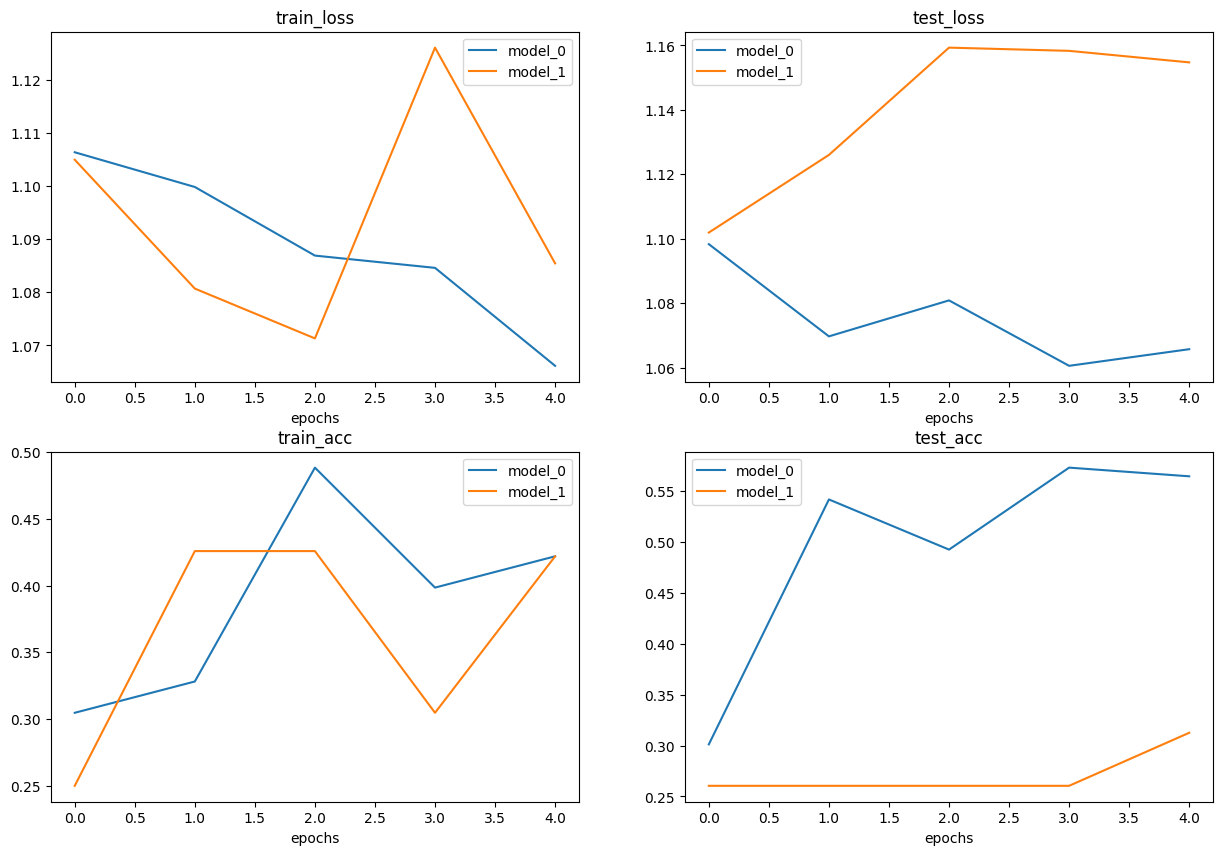

In [ ]:
# let's plot
# train_loss vs train_loss
# test_loss vs test_loss
# train_acc vs train_acc
# test_acc vs test_acc

plt.figure(figsize=(15,10))

epochs=range(len(model_0_pd))

# train_loss
plt.subplot(2,2,1)
plt.plot(epochs,model_0_pd["train_loss"],label="model_0")
plt.plot(epochs,model_1_pd["train_loss"],label="model_1")
plt.xlabel("epochs")
plt.title("train_loss")
plt.legend()

# test_loss
plt.subplot(2,2,2)
plt.plot(epochs,model_0_pd["test_loss"],label="model_0")
plt.plot(epochs,model_1_pd["test_loss"],label="model_1")
plt.xlabel("epochs")
plt.title("test_loss")
plt.legend()

# train_acc
plt.subplot(2,2,3)
plt.plot(epochs,model_0_pd["train_acc"],label="model_0")
plt.plot(epochs,model_1_pd["train_acc"],label="model_1")
plt.xlabel("epochs")
plt.title("train_acc")
plt.legend()

#test_acc
plt.subplot(2,2,4)
plt.plot(epochs,model_0_pd["test_acc"],label="model_0")
plt.plot(epochs,model_1_pd["test_acc"],label="model_1")
plt.xlabel("epochs")
plt.title("test_acc")
plt.legend()

# lets upload an image and try our model on

In [70]:
from pathlib import Path
import requests
image_path=data_path/"04-pizza-dad.jpg"
if not image_path.is_file():
  with open (image_path,"wb")as f:
    request=requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
    print(f"downloading our image {image_path}")
    f.write(request.content)
else:
  print(f"skipping downloading {image_path} as it already exists")

downloading our image data/04-pizza-dad.jpg


In [71]:
image_path

PosixPath('data/04-pizza-dad.jpg')

In [72]:
# image reading
import torchvision
custom_image_uint8=torchvision.io.read_image(str(image_path))
print(f"custom_image tensor : \n {custom_image_uint8} ")
print(f"custom_image shape : {custom_image_uint8.shape}")
print(f"custom_image dtype : {custom_image_uint8.dtype}")

custom_image tensor : 
 tensor([[[154, 173, 181,  ...,  21,  18,  14],
         [146, 165, 181,  ...,  21,  18,  15],
         [124, 146, 172,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 190, 193,  ...,  22,  19,  15],
         [163, 182, 193,  ...,  22,  19,  16],
         [141, 163, 184,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 107, 104, 103],
         [ 47,  38,  24,  ..., 108, 104, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[119, 138, 147,  ...,  17,  14,  10],
         [111, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  52,  52,  48],
         [ 27,  18,   4,  ...,  50,  49,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8) 
custom_image shape : torch.Size([3, 4032, 3024])
custom_image 

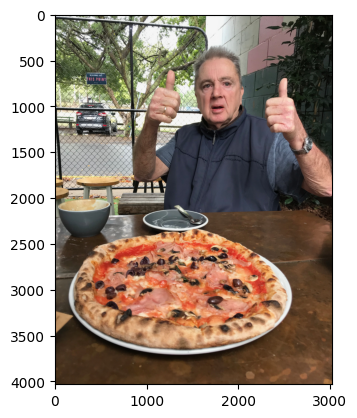

In [75]:
plt.imshow(custom_image_uint8.permute(1,2,0))